In [1]:
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoModel
import boto3
from google.cloud import storage
import torch

model_storage_folder = 'downloaded_models'

bucket_name = 'downloaded_llms'
model_list = ["openai-community_gpt2", "meta-llama_Llama-2-7b-hf", "google_gemma-2b-it", "facebook_opt-2.7b", "facebook_opt-125m"]



In [2]:
def load_model_from_path(model_name, bucket_name):
    client = storage.Client()
    bucket = client.bucket(bucket_name)
    prefix = f"{model_name}/" 
    blobs = bucket.list_blobs(prefix=prefix)
    model_files = [blob.name for blob in blobs if not blob.name.endswith('/')]
    return AutoModel.from_pretrained(model_files)

In [3]:
def download_files(model_name, bucket_name, local_path):
    client = storage.Client()
    bucket = client.bucket(bucket_name)
    prefix = f"{model_name}/" 
    blobs = bucket.list_blobs(prefix=prefix)
    
    os.makedirs(local_path, exist_ok=True)

    for blob in blobs:
        local_file_path = os.path.join(local_path, os.path.basename(blob.name))
        if not os.path.exists(local_file_path): 
            blob.download_to_filename(local_file_path)
            print(f"Downloaded {blob.name} to {local_file_path}.")


def load_model_from_path(model_name, bucket_name):
    local_path = f"./{model_name}"
    download_files(model_name, bucket_name, local_path)
    model = AutoModel.from_pretrained(local_path)
    return model, local_path


In [4]:
import shutil

def count_layers(model):
    layer_names = ['BertLayer', 'GPT2Block', 'T5Block', 'EncoderLayer', 'DecoderLayer', 'TransformerBlock']
    total_layers = 0
    for _, module in model.named_modules():
        if any(layer_name in module.__class__.__name__ for layer_name in layer_names):
            total_layers += 1

    return total_layers

def get_model_size(model_name, bucket_name):
    client = storage.Client()
    bucket = client.bucket(bucket_name)
    prefix = f"{model_name}/"
    blobs = bucket.list_blobs(prefix=prefix)
    total_size = sum(blob.size for blob in blobs)
    return total_size / (1024 * 1024)


def analyze_model_parameters(model):
    try:
        model_params = {name: param for name, param in model.named_parameters()}
        all_params = np.concatenate([p.data.cpu().numpy().flatten() for p in model_params.values()])
        
        stats = {
            'total_parameters': sum(p.numel() for p in model.parameters()),
            'total_parameter_tensors': len(list(model.parameters())),
            'min': np.min(all_params),
            'max': np.max(all_params),
            'percent_within_1_std': np.mean((all_params >= -1) & (all_params <= 1)) * 100
        }
        return stats
    except Exception as e:
        print(f"Error during analysis: {e}")
        return {'error': str(e)}
    finally:
        gc.collect()

def analyze_model_stats(model, model_name, bucket_name):
    try:
        param_stats= analyze_model_parameters(model)
        total_layers = count_layers(model)
        model_size_mb = get_model_size(model_name, bucket_name)
        
        stats = {
            'model_size_mb': model_size_mb,
            'total_layers': total_layers,
            **param_stats
        }
        return stats
    except Exception as e:
        print(f"Error during analysis of {model_name}: {e}")
        return {'error': str(e)} 

def cleanup_model_directory(local_path):
    shutil.rmtree(local_path)
    print(f"Deleted model files at {local_path}")
    
def update_histogram_incrementally(model, bin_edges, bin_counts):
    for param in model.parameters():
        flat_param = param.data.cpu().numpy().flatten()
        counts, _ = np.histogram(flat_param, bins=bin_edges)
        bin_counts += counts
    return bin_counts

def analyze_model_data_types(model):
    data_types_stats = {}
    total_size_bytes = 0

    for param in model.parameters():
        param_size_bytes = param.data.element_size() * param.data.nelement()
        total_size_bytes += param_size_bytes
        data_type = str(param.dtype)

        if data_type not in data_types_stats:
            data_types_stats[data_type] = {'count': 0, 'total_size_bytes': 0, 'total_elements': 0}
        
        data_types_stats[data_type]['count'] += 1
        data_types_stats[data_type]['total_size_bytes'] += param_size_bytes
        data_types_stats[data_type]['total_elements'] += param.data.nelement()

    for data_type, stats in data_types_stats.items():
        stats['total_size_gb'] = stats['total_size_bytes'] / (1024**3)
        stats['percent_total_size'] = (stats['total_size_bytes'] / total_size_bytes) * 100
        stats['avg_elements'] = stats['total_elements'] / stats['count']
        stats['avg_size_mb'] = (stats['total_size_bytes'] / (1024**2)) / stats['count']

    return data_types_stats

In [5]:
# main workflow
def collect_model_stats(model_list, bucket_name, bin_edges):
    bin_counts = np.zeros(len(bin_edges) - 1, dtype=int)
    model_stats = []
    all_data_types_stats = []
    for model_name in model_list:
        print(f"Starting model analysis for {model_name}...")
        
        model, local_path = load_model_from_path(model_name, bucket_name)
        stats = analyze_model_stats(model, model_name, bucket_name)
        stats['model_name'] = model_name
        model_stats.append(stats)
        
        bin_counts = update_histogram_incrementally(model, bin_edges, bin_counts)
        
        data_types_stats = analyze_model_data_types(model)
        all_data_types_stats.append({'model_name': model_name, 'data_types_stats': data_types_stats})
        
        cleanup_model_directory(local_path)
        gc.collect()
        
        print(f"Completed model analysis for {model_name}.")
    
    data_list = [
        {
            'Layer Type': dtype,
            'Count': stats['count'],
            'Total Sz in GB': f"{stats['total_size_gb']:.2f} ({stats['percent_total_size']:.2f}%)",
            'Avg Para #': int(stats['avg_elements']),
            'Avg Sz in MB': f"{stats['avg_size_mb']:.2f}"
        }
        for model_stat in all_data_types_stats
        for dtype, stats in model_stat['data_types_stats'].items()
    ]
    df_stats = pd.DataFrame(data_list)
    return pd.DataFrame(model_stats), bin_counts, df_stats


In [6]:
model_list = ["openai-community_gpt2", "google_gemma-2b-it", "facebook_opt-2.7b", "facebook_opt-125m"]
bin_edges = np.linspace(-3, 3, num=30)
model_statistics, bin_counts, df_stats = collect_model_stats(model_list, bucket_name, bin_edges)


Starting model analysis for openai-community_gpt2...
Downloaded openai-community_gpt2/config.json to ./openai-community_gpt2/config.json.
Downloaded openai-community_gpt2/pytorch_model.bin to ./openai-community_gpt2/pytorch_model.bin.
Deleted model files at ./openai-community_gpt2
Completed model analysis for openai-community_gpt2.
Starting model analysis for google_gemma-2b-it...
Downloaded google_gemma-2b-it/config.json to ./google_gemma-2b-it/config.json.
Downloaded google_gemma-2b-it/pytorch_model.bin to ./google_gemma-2b-it/pytorch_model.bin.


Gemma's activation function should be approximate GeLU and not exact GeLU.
Changing the activation function to `gelu_pytorch_tanh`.if you want to use the legacy `gelu`, edit the `model.config` to set `hidden_activation=gelu`   instead of `hidden_act`. See https://github.com/huggingface/transformers/pull/29402 for more details.


Deleted model files at ./google_gemma-2b-it
Completed model analysis for google_gemma-2b-it.
Starting model analysis for facebook_opt-2.7b...
Downloaded facebook_opt-2.7b/config.json to ./facebook_opt-2.7b/config.json.
Downloaded facebook_opt-2.7b/pytorch_model.bin to ./facebook_opt-2.7b/pytorch_model.bin.
Deleted model files at ./facebook_opt-2.7b
Completed model analysis for facebook_opt-2.7b.
Starting model analysis for facebook_opt-125m...
Downloaded facebook_opt-125m/config.json to ./facebook_opt-125m/config.json.
Downloaded facebook_opt-125m/pytorch_model.bin to ./facebook_opt-125m/pytorch_model.bin.
Deleted model files at ./facebook_opt-125m
Completed model analysis for facebook_opt-125m.


In [7]:
print(model_statistics)

   model_size_mb  total_layers  total_parameters  total_parameter_tensors  \
0     474.749109            12         124439808                      148   
1    9560.352129            18        2506172416                      164   
2   10115.219238            32        2651596800                      516   
3     477.817388            12         125239296                      196   

         min        max  percent_within_1_std             model_name  
0 -11.050447  17.419317             99.988236  openai-community_gpt2  
1  -9.750000  14.312500             99.947758     google_gemma-2b-it  
2  -0.500000   1.000000            100.000000      facebook_opt-2.7b  
3  -1.231445   1.560547             99.999347      facebook_opt-125m  


In [8]:
print(df_stats)

      Layer Type  Count  Total Sz in GB  Avg Para # Avg Sz in MB
0  torch.float32    148  0.46 (100.00%)      840809         3.21
1  torch.float32    164  9.34 (100.00%)    15281539        58.29
2  torch.float32    516  9.88 (100.00%)     5138753        19.60
3  torch.float32    196  0.47 (100.00%)      638976         2.44


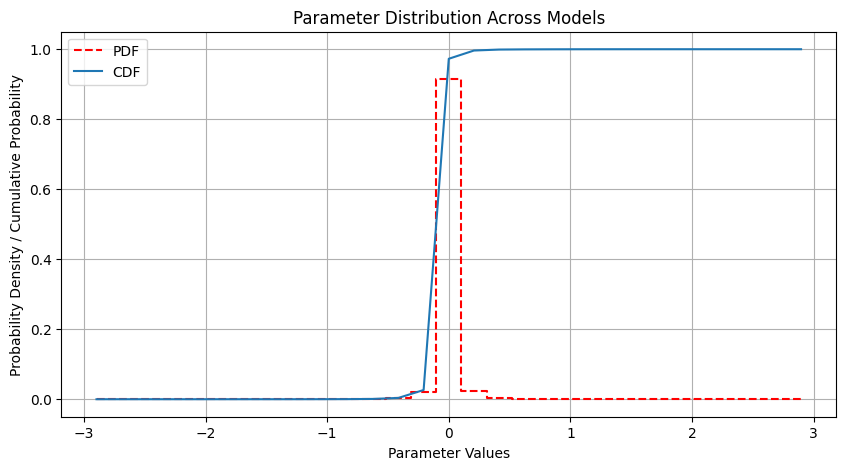

In [9]:
pdf = bin_counts / (np.sum(bin_counts) * np.diff(bin_edges)) / 5
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

cdf = np.cumsum(pdf * np.diff(bin_edges)) * 5


plt.figure(figsize=(10, 5))
plt.plot(bin_centers, pdf, drawstyle='steps-mid', linestyle='--', color='red', label='PDF')
plt.plot(bin_centers, cdf, label='CDF')
plt.xlabel('Parameter Values')
plt.ylabel('Probability Density / Cumulative Probability')
plt.title('Parameter Distribution Across Models')
plt.legend(loc='best')
plt.grid(True)
plt.show()


In [10]:
def calculate_cdf(data):
    data_sorted = np.sort(data)
    cdf = np.arange(1, len(data_sorted) + 1) / float(len(data_sorted))
    return data_sorted, cdf

size_sorted, size_cdf = calculate_cdf(model_statistics['model_size_mb'])
params_sorted, params_cdf = calculate_cdf(model_statistics['total_parameters'])
layers_sorted, layers_cdf = calculate_cdf(model_statistics['total_layers'])

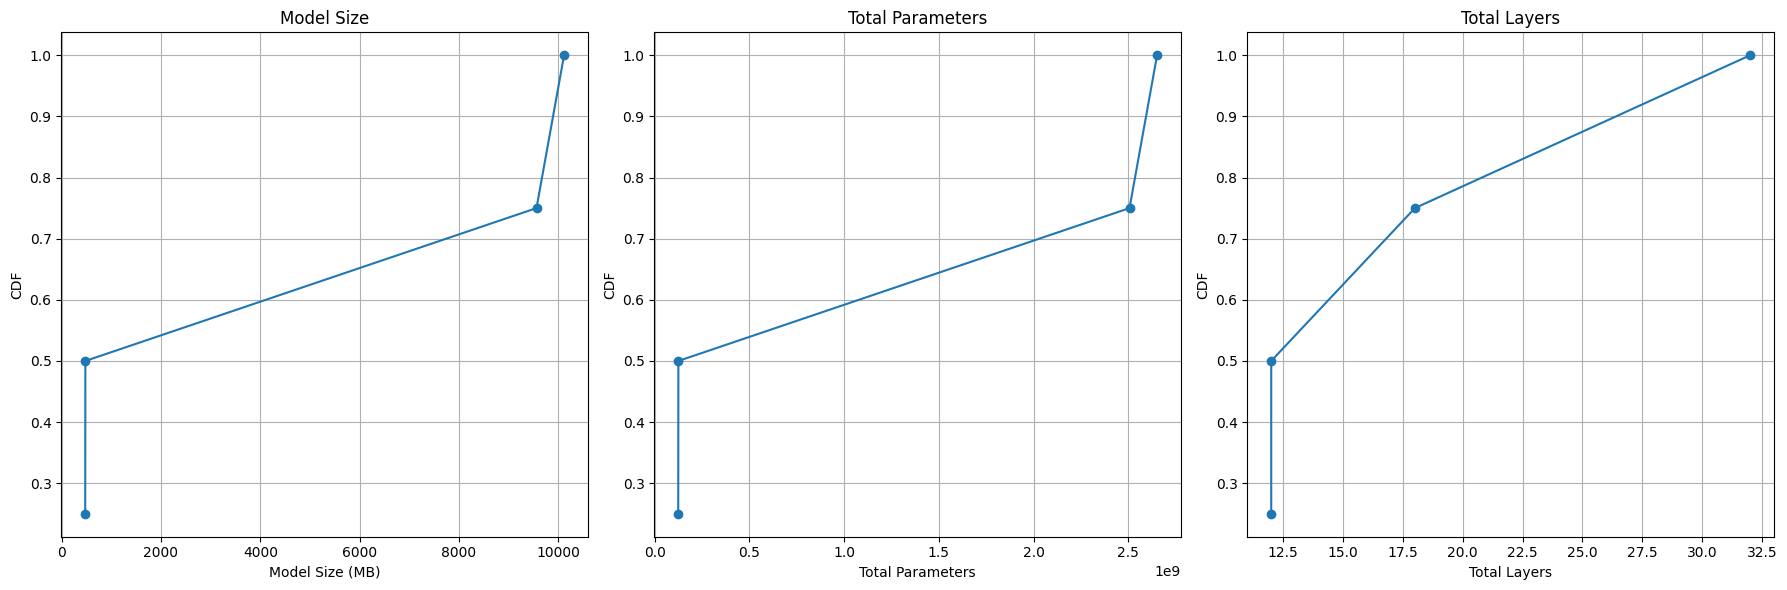

In [11]:
plt.figure(figsize=(18, 6))

# model size in MB
plt.subplot(1, 3, 1)
plt.plot(size_sorted, size_cdf, marker='o')
plt.xlabel('Model Size (MB)')
plt.ylabel('CDF')
plt.title('Model Size')
plt.grid(True)

# number of parameters
plt.subplot(1, 3, 2)
plt.plot(params_sorted, params_cdf, marker='o')
plt.xlabel('Total Parameters')
plt.ylabel('CDF')
plt.title('Total Parameters')
plt.grid(True)

# layer count
plt.subplot(1, 3, 3)
plt.plot(layers_sorted, layers_cdf, marker='o')
plt.xlabel('Total Layers')
plt.ylabel('CDF')
plt.title('Total Layers')
plt.grid(True)

plt.tight_layout()
plt.show()